In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from difflib import get_close_matches

# TODO: Update these file paths to point to '02_proprietary_methanol/data/processed'
INVENTORY_PATH = "/02_proprietary_methanol/data/processed/Inventory.csv"
IMPACT_FACTORS_PATH = "/02_proprietary_methanol/data/processed/GreenImpactFactors.csv"


In [18]:
def norm(s: str) -> str:
    if pd.isna(s): return ""
    s = str(s)
    s = (s.replace("\u202f"," ").replace("\u00a0"," ")
           .replace("\u2011","-").replace("\u2013","-").replace("\u2014","-"))
    return re.sub(r"\s+"," ",s).strip().lower()

def find_col(df: pd.DataFrame, tokens) -> str:
    for c in df.columns:
        cl = c.lower()
        if all(t.lower() in cl for t in tokens):
            return c
    raise KeyError(f"Column with tokens {tokens} not found. Columns: {list(df.columns)}")


In [19]:
inv_raw = pd.read_csv(INVENTORY_PATH)
imp_raw = pd.read_csv(IMPACT_FACTORS_PATH)

display(inv_raw.head(16))
display(imp_raw.head(16))


,Raw Material,Value,Unit
0,Air,26945.00000,kg/t-PHA
1,Biomass,0.00568,kg/t-PHA
2,CIP-Caustic,489.00000,kg/t-PHA
3,Ethyl Alcohol,17.00000,kg/t-PHA
4,HCl (20% w/w),4.00000,kg/t-PHA
5,NAOH (20% w/w),84.00000,kg/t-PHA
6,Natural Gas,17.00000,kg/t-PHA
7,NH3 (29% w/w),118.00000,kg/t-PHA
8,Protease,1.00000,kg/t-PHA
9,RO Water,18512.00000,kg/t-PHA


,Impact Category Units,kg CO2-eq
0,Air,0.000
1,Biomass,1.780
2,CIP-Caustic,1.120
3,Ethyl Alcohol,1.010
4,HCl (20% w/w),0.178
5,NAOH (20% w/w),1.120
6,Natural Gas,2.308
7,NH3 (29% w/w),1.690
8,Protease,14.330
9,RO Water,0.000


In [20]:
cat_col = find_col(imp_raw, ["impact","category"])
kg_col  = find_col(imp_raw, ["co2","kg"])

EXCLUDE = {"incineration","landfill","composting","recycling"}
imp = imp_raw[~imp_raw[cat_col].astype(str).str.strip().str.lower().isin(EXCLUDE)].copy()

imp["_key"] = imp[cat_col].map(norm)
imp[kg_col] = pd.to_numeric(imp[kg_col], errors="coerce")

factor_lookup = dict(zip(imp["_key"], imp[kg_col]))
factor_keys = list(factor_lookup.keys())
print(f"Impact-factor rows kept: {len(imp)}")


Impact-factor rows kept: 15


In [21]:
SECTION_HEADERS = ["Electricity consumption", "Steam", "Water", "Transportation"]
SECTION_HEADERS_N = [norm(x) for x in SECTION_HEADERS]

rows, current_section = [], None
for _, r in inv_raw.iterrows():
    name = str(r.get("Raw Material","")).strip()
    val  = pd.to_numeric(r.get("Value", np.nan), errors="coerce")
    unit = r.get("Unit","")

    if norm(name) in SECTION_HEADERS_N and pd.isna(val):
        current_section = name
        continue
    if not name or pd.isna(val):
        continue

    rows.append({"Item": name, "Section": current_section, "Value": val, "Unit": unit})

inv = pd.DataFrame(rows).reset_index(drop=True)

def assign_category(row):
    if pd.notna(row["Section"]):
        return row["Section"]
    if norm(row["Item"]) == norm("CH3OH"):
        return "Methanol"
    if norm(row["Item"]) == norm("Water"):
        return "Water"
    if norm(row["Item"]) == norm("Electricity"):
        return "Electricity"
    return "Chemicals"   # roll all other raw materials together

inv["Category"] = inv.apply(assign_category, axis=1)
display(inv.head(16))


,Item,Section,Value,Unit,Category
0,Air,None,26945.00000,kg/t-PHA,Chemicals
1,Biomass,None,0.00568,kg/t-PHA,Chemicals
2,CIP-Caustic,None,489.00000,kg/t-PHA,Chemicals
3,Ethyl Alcohol,None,17.00000,kg/t-PHA,Chemicals
4,HCl (20% w/w),None,4.00000,kg/t-PHA,Chemicals
5,NAOH (20% w/w),None,84.00000,kg/t-PHA,Chemicals
6,Natural Gas,None,17.00000,kg/t-PHA,Chemicals
7,NH3 (29% w/w),None,118.00000,kg/t-PHA,Chemicals
8,Protease,None,1.00000,kg/t-PHA,Chemicals
9,RO Water,None,18512.00000,kg/t-PHA,Chemicals


In [22]:
def factor_key_for_row(row):
    cat_n, item_n = norm(row["Category"]), norm(row["Item"])

    key = item_n  # chemicals: use specific item name

    if key in factor_lookup:
        return key
    m = get_close_matches(key, factor_keys, n=1, cutoff=0.85)
    return m[0] if m else None

inv["_factor_key"] = inv.apply(factor_key_for_row, axis=1)
inv["Factor (kg CO2-eq / unit)"] = inv["_factor_key"].map(factor_lookup)

unmapped = inv[inv["Factor (kg CO2-eq / unit)"].isna()][["Item","Category"]].drop_duplicates()
if len(unmapped):
    print("⚠️ Unmapped items — add/rename in Impactfactors.csv or tweak mapping:")
    display(unmapped)
else:
    print("✅ All items matched to impact factors.")


✅ All items matched to impact factors.


In [23]:
# Categories in your inventory that are per-ton PHA and need /1000
PER_TON_CATS = ["Methanol","Electricity","Chemicals","Water","Placeholder"]
# Categories already per-kg (leave as-is)
PER_KG_CATS  = ["Steam"]  # extend if needed

def compute_impact(row):
    val = row["Value"] * row["Factor (kg CO2-eq / unit)"]
    if row["Category"] in PER_TON_CATS:
        return val / 1000.0     # convert per ton → per kg
    else:
        return val              # already per kg

inv["Impact (kg CO2-eq)"] = inv.apply(compute_impact, axis=1)

matched = inv.dropna(subset=["Impact (kg CO2-eq)"]).copy()
by_cat = matched.groupby("Category", as_index=False)["Impact (kg CO2-eq)"].sum()
print("Per-kg contributions (top):")
display(by_cat.sort_values("Impact (kg CO2-eq)", ascending=False).head(10))



Per-kg contributions (top):


,Category,Impact (kg CO2-eq)
1,Electricity,0.932768
0,Chemicals,0.930594
3,Water,0.096360
2,Methanol,-4.209840


In [24]:
# Hard-coded additional categories (all in per-kg CO2-eq units)
#extras = {
#    "Placeholder": 0,
#}

#extras_df = (
#    pd.Series(extras, name="Impact (kg CO2-eq)")
#      .rename_axis("Category")
#      .reset_index()
#)

cat_plus = (
    pd.concat([by_cat,
               #extras_df
               ], ignore_index=True)
      .groupby("Category", as_index=False)["Impact (kg CO2-eq)"].sum()
)

display(cat_plus.sort_values("Impact (kg CO2-eq)", ascending=False))


,Category,Impact (kg CO2-eq)
1,Electricity,0.932768
0,Chemicals,0.930594
3,Water,0.096360
2,Methanol,-4.209840


In [25]:
ordered_categories = [
    "Methanol","Electricity","Chemicals","Water"]
xlabels = [
    "Methanol","Electricity","Chemicals","Water"]

vals = [cat_plus.loc[cat_plus["Category"].eq(c), "Impact (kg CO2-eq)"].sum()
        for c in ordered_categories]
vals = [0.0 if pd.isna(v) else float(v) for v in vals]

bottoms = [0.0]
for i in range(1, len(vals)):
    bottoms.append(bottoms[-1] + vals[i-1])

subtotal = sum(vals)
print(f"Sanity: Methanol={vals[0]:.2f}, Electricity={vals[3]:.2f}, Chemicals={vals[3]:.4f}, Subtotal={subtotal:.2f}")


Sanity: Methanol=-4.21, Electricity=0.10, Chemicals=0.0964, Subtotal=-2.25


Saved: green_waterfall.png


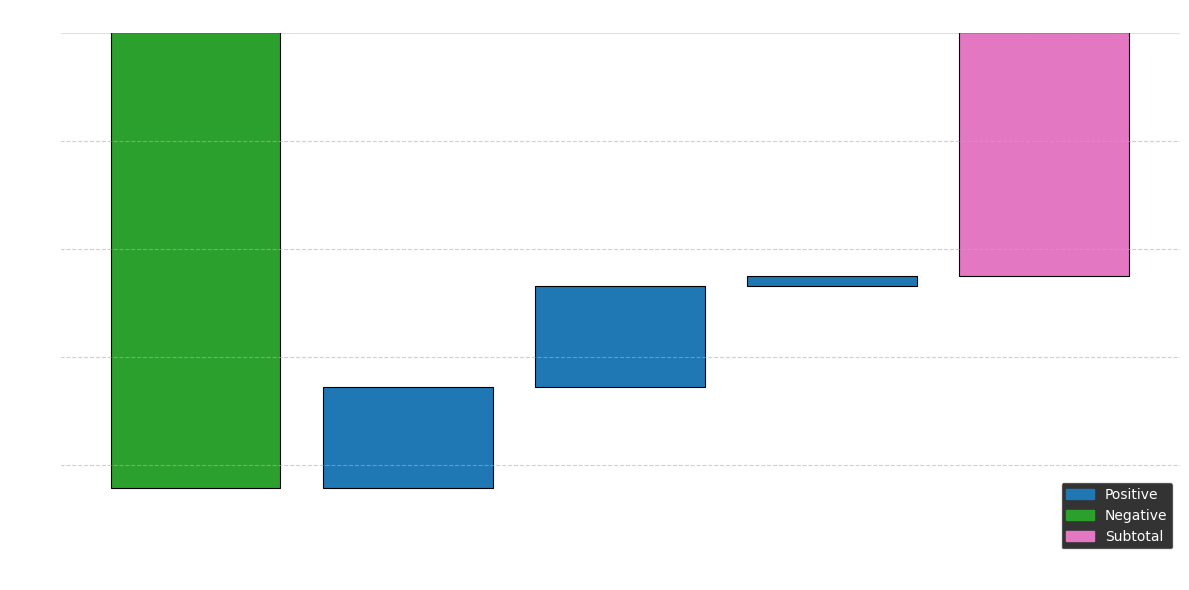

In [26]:

fig_pha, ax = plt.subplots(figsize=(12, 6))

for i, (v, b) in enumerate(zip(vals, bottoms)):
    ax.bar(i, v, bottom=b, color=("tab:blue" if v >= 0 else "tab:green"),
           edgecolor="black", linewidth=0.8)

# Subtotal bar
ax.bar(len(vals), subtotal, color="tab:pink", edgecolor="black", linewidth=0.8)

xlabels_plot = xlabels + ["Subtotal"]
ax.set_xticks(range(len(xlabels_plot)))
ax.set_xticklabels(xlabels_plot, rotation=45, ha="right")

ax.set_ylabel("Carbon footprint (kgCO₂-eq / kg-polymer)")
ax.set_title("Green Methanol to Bio-based polymer (PHA)")

# Zero line + grid
ax.axhline(0, linewidth=1, color="black", alpha=0.6)
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Value labels
tops = [b+v for b, v in zip(bottoms, vals)]
pad = 0.08 * max(1.0, max(abs(min([0]+bottoms+tops)), abs(max([0]+bottoms+tops))))
for i, v in enumerate(vals + [subtotal]):
    y = (tops[i] if i < len(tops) else subtotal)
    ax.text(i, y + (pad if v >= 0 else -pad), f"{v:.2f}",
            ha="center", va=("bottom" if v >= 0 else "top"), fontsize=9, color="white")

# Nice y-limits so nothing clips
ymin = min(0, *(bottoms + tops))
ymax = max(0, *(bottoms + tops))
ax.set_ylim(ymin - 0.15*abs(ymin if ymin else ymax), ymax + 0.15*abs(ymax))

# Make all text white for dark background
ax.title.set_color("white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.tick_params(axis="x", colors="white", labelrotation=0)
ax.tick_params(axis="y", colors="white")

# If you want the spines (box edges) white too
for spine in ax.spines.values():
    spine.set_color("white")

# Legend (manual color mapping)
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, color="tab:blue", label="Positive"),
    plt.Rectangle((0, 0), 1, 1, color="tab:green", label="Negative"),
    plt.Rectangle((0, 0), 1, 1, color="tab:pink", label="Subtotal")
]
ax.legend(handles=legend_elements, loc="best", facecolor="black", edgecolor="white", labelcolor="white")


fig_pha.tight_layout()

# Save the SAME figure you plotted
out_path = "green_waterfall.png"
fig_pha.savefig(out_path, dpi=300, bbox_inches="tight", transparent=True)
print("Saved:", out_path)




plt.show()
